# Intelligent Study Assistant using NLP and Retrieval-Augmented Generation (RAG)

**BCA 5th Semester NLP Project**

## Project overview
This notebook builds and evaluates a small study assistant that retrieves relevant passages from PDF study material and returns an extractive answer with its source page.

### Pipeline
1. Load a PDF and extract page-wise text.
2. Clean and tokenize text for inspection.
3. Split page text into overlapping chunks.
4. Convert chunks into sentence embeddings.
5. Retrieve relevant chunks with FAISS.
6. Compare semantic retrieval against a TF-IDF baseline.
7. Generate an extractive answer from retrieved source sentences.
8. Evaluate retrieval on a small, manually labelled test set and visualize results.

> **Scope note:** This notebook uses extractive answer selection, not an LLM. It does not require an API key. The sample PDF is a test document; replace or supplement it with course material before final evaluation.

## 1. Import libraries and check the input PDF

Run this notebook from the project root folder, `IntelligentStudyAssistant`, so the relative PDF path below resolves correctly.

In [1]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymupdf
import nltk
import faiss

from nltk.tokenize import word_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pdfPath = os.path.join(
    "data",
    "study_material",
    "NLP_Study_Notes_for_RAG_Test.pdf"
)

print("PDF exists:", os.path.exists(pdfPath))
if not os.path.exists(pdfPath):
    raise FileNotFoundError(
        f"PDF not found at {pdfPath}. Run this notebook from the project root "
        "and check the data/study_material folder."
    )
print("Libraries imported successfully.")

d:\NLP Project\IntelligentStudyAssistant\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PDF exists: True
Libraries imported successfully.


## 2. Extract text from the PDF

Text is extracted page by page so that every chunk and answer can retain its source page number.

In [2]:
pages = []

with pymupdf.open(pdfPath) as document:
    for pageNumber, page in enumerate(document, start=1):
        pageText = page.get_text()
        if pageText.strip():
            pages.append({
                "page": pageNumber,
                "text": pageText
            })

if not pages:
    raise ValueError(
        "No selectable text was found in the PDF. If it is a scanned PDF, OCR is needed."
    )

print("Pages with text:", len(pages))
print("\nPreview of page 1:\n")
print(pages[0]["text"][:1000])

Pages with text: 6

Preview of page 1:

NLP Study Notes — Intelligent Study Assistant
Page 1
Natural Language Processing (NLP)
Study Notes for Testing an Intelligent Study Assistant
These notes cover basic NLP concepts, text preprocessing, embeddings, semantic search, and
Retrieval-Augmented Generation (RAG). The document is intentionally text-based so it can be used
to test PDF text extraction in a student project.
Learning objectives
• Explain what NLP is and identify common applications.
• Describe tokenization, stop-word removal, stemming, and lemmatization.
• Understand the difference between keyword search and semantic search.
• Explain how embeddings, vector databases, retrieval, and RAG work together.



## 3. Text cleaning and tokenization

Whitespace is normalized and NLTK tokenization is used to inspect the extracted text. We preserve the original page text for retrieval rather than aggressively removing words that may affect a question's meaning.

In [3]:
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

rawText = "\n".join(page["text"] for page in pages)
cleanText = re.sub(r"\s+", " ", rawText).strip()
tokens = word_tokenize(cleanText)

print("Original text length:", len(rawText))
print("Clean text length:", len(cleanText))
print("Token count:", len(tokens))
print("First 30 tokens:", tokens[:30])

Original text length: 8143
Clean text length: 8137
Token count: 1465
First 30 tokens: ['NLP', 'Study', 'Notes', '—', 'Intelligent', 'Study', 'Assistant', 'Page', '1', 'Natural', 'Language', 'Processing', '(', 'NLP', ')', 'Study', 'Notes', 'for', 'Testing', 'an', 'Intelligent', 'Study', 'Assistant', 'These', 'notes', 'cover', 'basic', 'NLP', 'concepts', ',']


## 4. Split text into overlapping chunks

Chunking keeps passages small enough for retrieval while overlap helps avoid losing context at chunk boundaries. Page metadata is retained for source display.

In [4]:
chunkSize = 800
overlap = 200

if chunkSize <= 0 or overlap < 0 or overlap >= chunkSize:
    raise ValueError("Use chunkSize > overlap >= 0.")

chunks = []

for page in pages:
    pageText = re.sub(r"\s+", " ", page["text"]).strip()
    start = 0

    while start < len(pageText):
        end = start + chunkSize
        chunkText = pageText[start:end].strip()

        if chunkText:
            chunks.append({
                "page": page["page"],
                "text": chunkText
            })

        start += chunkSize - overlap

if not chunks:
    raise ValueError("No text chunks were created.")

chunkTexts = [chunk["text"] for chunk in chunks]

print("Total chunks:", len(chunks))
print("First chunk source page:", chunks[0]["page"])
print("\nFirst chunk preview:\n", chunks[0]["text"][:700])

Total chunks: 18
First chunk source page: 1

First chunk preview:
 NLP Study Notes — Intelligent Study Assistant Page 1 Natural Language Processing (NLP) Study Notes for Testing an Intelligent Study Assistant These notes cover basic NLP concepts, text preprocessing, embeddings, semantic search, and Retrieval-Augmented Generation (RAG). The document is intentionally text-based so it can be used to test PDF text extraction in a student project. Learning objectives • Explain what NLP is and identify common applications. • Describe tokenization, stop-word removal, stemming, and lemmatization. • Understand the difference between keyword search and semantic search. • Explain how embeddings, vector databases, retrieval, and RAG work together.


## 5. Create embeddings for the chunks

The `all-MiniLM-L6-v2` sentence-transformer maps each chunk to a dense numerical vector. Similar meanings can be close in vector space even if the exact words differ. The model may download the first time it is used.

In [5]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    chunkTexts,
    convert_to_numpy=True,
    show_progress_bar=True
).astype("float32")

print("Number of chunks:", len(chunkTexts))
print("Embedding matrix shape:", embeddings.shape)

Batches: 100%|██████████| 1/1 [00:04<00:00,  4.64s/it]

Number of chunks: 18
Embedding matrix shape: (18, 384)


## 6. Build the FAISS vector index

Embeddings are L2-normalized, then stored in a FAISS inner-product index. For normalized vectors, inner product corresponds to cosine similarity.

In [6]:
embeddingDimension = embeddings.shape[1]
normalizedEmbeddings = embeddings.copy()
faiss.normalize_L2(normalizedEmbeddings)

vectorIndex = faiss.IndexFlatIP(embeddingDimension)
vectorIndex.add(normalizedEmbeddings)

print("FAISS index created.")
print("Vectors stored:", vectorIndex.ntotal)
print("Vector dimensions:", vectorIndex.d)

FAISS index created.
Vectors stored: 18
Vector dimensions: 384


## 7. Test semantic retrieval with one question

The top passages are printed with similarity scores and page numbers. Similarity is a ranking signal, not proof that a passage fully answers the question.

In [7]:
query = "What is Retrieval-Augmented Generation?"

queryEmbedding = model.encode(
    [query],
    convert_to_numpy=True
).astype("float32")
faiss.normalize_L2(queryEmbedding)

topK = min(3, len(chunks))
scores, indices = vectorIndex.search(queryEmbedding, k=topK)

for rank, (score, index) in enumerate(zip(scores[0], indices[0]), start=1):
    print(f"\nResult {rank} | Similarity: {float(score):.4f}")
    print("Source page:", chunks[int(index)]["page"])
    print(chunks[int(index)]["text"][:500])


Result 1 | Similarity: 0.5965
Source page: 5
NLP Study Notes — Intelligent Study Assistant Page 5 4. Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation. Instead of relying only on information learned during model training, a RAG system retrieves relevant passages from a supplied collection and uses them as context when generating an answer. Main stages of a RAG system • Document loading: read study material from PDF or other supported formats. • 

Result 2 | Similarity: 0.4041
Source page: 1
• Explain how embeddings, vector databases, retrieval, and RAG work together.

Result 3 | Similarity: 0.3748
Source page: 6
t context, or generate an incorrect answer. Scanned PDFs may require OCR if they contain images rather than selectable text. Embedding models and language models may need an initial download, and generation may require a separate model or service. Users should verify important answe

## 8. Build a TF-IDF retrieval baseline

TF-IDF ranks chunks by word overlap. This provides a simple baseline to compare against semantic retrieval.

In [8]:
tfidfVectorizer = TfidfVectorizer(stop_words="english")
tfidfMatrix = tfidfVectorizer.fit_transform(chunkTexts)

query = "What is Retrieval-Augmented Generation?"
queryVector = tfidfVectorizer.transform([query])
tfidfScores = cosine_similarity(queryVector, tfidfMatrix)[0]
topIndices = tfidfScores.argsort()[::-1][:min(3, len(chunks))]

for rank, index in enumerate(topIndices, start=1):
    print(f"\nResult {rank} | TF-IDF score: {tfidfScores[index]:.4f}")
    print("Source page:", chunks[int(index)]["page"])
    print(chunks[int(index)]["text"][:400])


Result 1 | TF-IDF score: 0.3900
Source page: 5
NLP Study Notes — Intelligent Study Assistant Page 5 4. Retrieval-Augmented Generation (RAG) Retrieval-Augmented Generation (RAG) is an approach that combines information retrieval with text generation. Instead of relying only on information learned during model training, a RAG system retrieves relevant passages from a supplied collection and uses them as context when generating an answer. Main st

Result 2 | TF-IDF score: 0.1987
Source page: 1
NLP Study Notes — Intelligent Study Assistant Page 1 Natural Language Processing (NLP) Study Notes for Testing an Intelligent Study Assistant These notes cover basic NLP concepts, text preprocessing, embeddings, semantic search, and Retrieval-Augmented Generation (RAG). The document is intentionally text-based so it can be used to test PDF text extraction in a student project. Learning objectives 

Result 3 | TF-IDF score: 0.1370
Source page: 1
• Explain how embeddings, vector databases, retrieval,

## 9. Compare retrieval methods on test questions

The expected page labels below are **manual relevance judgements** based on the supplied six-page test PDF, not labels learned by the system. Page 4 contains the explanation of embeddings; page 3 covers preprocessing; page 5 covers RAG; and page 6 covers evaluation and limitations.

Precision@1 is the fraction of test questions for which the top-ranked chunk comes from an expected relevant page. Since this is a tiny test set, treat the score as a demonstration rather than a general performance claim.

In [9]:
testQueries = [
    "What is Retrieval-Augmented Generation?",
    "What is the role of embeddings?",
    "Why is text preprocessing needed?",
    "How can retrieval quality be evaluated?",
    "What are the limitations of a RAG system?"
]

relevantPages = {
    "What is Retrieval-Augmented Generation?": [5],
    "What is the role of embeddings?": [4],
    "Why is text preprocessing needed?": [3],
    "How can retrieval quality be evaluated?": [6],
    "What are the limitations of a RAG system?": [6]
}

evaluationRows = []

for testQuery, expectedPages in relevantPages.items():
    tfidfScores = cosine_similarity(
        tfidfVectorizer.transform([testQuery]), tfidfMatrix
    )[0]
    tfidfIndex = int(tfidfScores.argmax())
    tfidfPage = chunks[tfidfIndex]["page"]

    queryEmbedding = model.encode(
        [testQuery], convert_to_numpy=True
    ).astype("float32")
    faiss.normalize_L2(queryEmbedding)
    faissScores, faissIndices = vectorIndex.search(queryEmbedding, k=1)
    faissIndex = int(faissIndices[0][0])
    faissPage = chunks[faissIndex]["page"]

    evaluationRows.append({
        "Question": testQuery,
        "Expected relevant page(s)": ", ".join(map(str, expectedPages)),
        "TF-IDF top page": tfidfPage,
        "TF-IDF hit": tfidfPage in expectedPages,
        "FAISS top page": faissPage,
        "FAISS hit": faissPage in expectedPages,
        "FAISS similarity": round(float(faissScores[0][0]), 4)
    })

evaluationResults = pd.DataFrame(evaluationRows)
display(evaluationResults)

tfidfPrecisionAt1 = evaluationResults["TF-IDF hit"].mean()
faissPrecisionAt1 = evaluationResults["FAISS hit"].mean()

print(f"TF-IDF Precision@1: {tfidfPrecisionAt1:.2f}")
print(f"Embeddings + FAISS Precision@1: {faissPrecisionAt1:.2f}")

,Question,Expected relevant page(s),TF-IDF top page,TF-IDF hit,FAISS top page,FAISS hit,FAISS similarity
0,What is Retrieval-Augmented Generation?,5,5,True,5,True,0.5965
1,What is the role of embeddings?,4,1,False,1,False,0.6352
2,Why is text preprocessing needed?,3,3,True,3,True,0.6671
3,How can retrieval quality be evaluated?,6,2,False,6,True,0.4983
4,What are the limitations of a RAG system?,6,1,False,1,False,0.3838


TF-IDF Precision@1: 0.40
Embeddings + FAISS Precision@1: 0.60


## 10. Extractive answer generation

This project does not call a generative language model. Instead, it retrieves the top passages and selects the most relevant complete sentence from those passages. The answer stays grounded in the PDF and includes a source page.

The sentence selector uses semantic similarity plus a small lexical-overlap signal. Headings and question-style lines are filtered where possible. Always verify the answer against its source passage.

In [10]:
def cleanCandidateSentence(sentence):
    sentence = re.sub(r"^[\s•\-–]+", "", sentence).strip()
    sentence = re.sub(
        r"^NLP Study Notes\s*[—-]\s*Intelligent Study Assistant\s*Page\s*\d+\s*",
        "",
        sentence,
        flags=re.IGNORECASE
    )
    headingPatterns = [
        r"^\d+\.\s*Introduction to NLP\s*",
        r"^\d+\.\s*Text Preprocessing\s*",
        r"^\d+\.\s*Text Representations and Embeddings\s*",
        r"^\d+\.\s*Retrieval-Augmented Generation\s*\(RAG\)\s*",
        r"^\d+\.\s*Evaluating a Study Assistant\s*",
        r"^Limitations and responsible use\s*",
        r"^Possible evaluation measures\s*",
        r"^Why preprocessing matters\s*",
        r"^Main stages of a RAG system\s*",
        r"^Cosine similarity\s*",
        r"^Common applications\s*",
        r"^Typical NLP pipeline\s*",
        r"^Learning objectives\s*"
    ]
    for pattern in headingPatterns:
        sentence = re.sub(pattern, "", sentence, flags=re.IGNORECASE).strip()

    # Remove a duplicated heading phrase when PDF extraction repeats it before the sentence.
    sentence = re.sub(
        r"^(.{8,75}?)\s+\1\b",
        r"\1",
        sentence,
        flags=re.IGNORECASE
    )
    return re.sub(r"\s+", " ", sentence).strip()


def generateAnswer(query, topK=5):
    if not query or not query.strip():
        return {
            "answer": "Please enter a question.",
            "source_page": None,
            "retrieval_score": None
        }

    query = query.strip()
    queryEmbedding = model.encode(
        [query], convert_to_numpy=True
    ).astype("float32")
    faiss.normalize_L2(queryEmbedding)

    k = min(topK, len(chunks))
    retrievalScores, retrievalIndices = vectorIndex.search(queryEmbedding, k=k)

    candidates = []
    candidatePages = []
    candidateChunkScores = []

    for retrievalScore, chunkIndex in zip(retrievalScores[0], retrievalIndices[0]):
        chunk = chunks[int(chunkIndex)]
        sentences = re.split(r"(?<=[.!?])\s+", chunk["text"])

        for sentence in sentences:
            sentence = cleanCandidateSentence(sentence)

            if len(sentence.split()) < 8:
                continue
            if sentence.endswith(":") or "?" in sentence:
                continue
            if re.fullmatch(r"[\W\d_]+", sentence):
                continue

            candidates.append(sentence)
            candidatePages.append(chunk["page"])
            candidateChunkScores.append(float(retrievalScore))

    if not candidates:
        bestChunkIndex = int(retrievalIndices[0][0])
        return {
            "answer": chunks[bestChunkIndex]["text"],
            "source_page": chunks[bestChunkIndex]["page"],
            "retrieval_score": float(retrievalScores[0][0])
        }

    sentenceEmbeddings = model.encode(
        candidates, convert_to_numpy=True, show_progress_bar=False
    ).astype("float32")
    faiss.normalize_L2(sentenceEmbeddings)

    semanticScores = sentenceEmbeddings @ queryEmbedding[0]

    lexicalVectorizer = TfidfVectorizer(stop_words="english")
    try:
        lexicalMatrix = lexicalVectorizer.fit_transform(candidates + [query])
        lexicalScores = cosine_similarity(
            lexicalMatrix[-1], lexicalMatrix[:-1]
        )[0]
    except ValueError:
        lexicalScores = np.zeros(len(candidates), dtype="float32")

    # Semantic relevance is the main signal; lexical overlap breaks close ties.
    combinedScores = 0.8 * semanticScores + 0.2 * lexicalScores
    bestIndex = int(np.argmax(combinedScores))

    return {
        "answer": candidates[bestIndex],
        "source_page": candidatePages[bestIndex],
        "retrieval_score": candidateChunkScores[bestIndex]
    }

## 11. Test the answer generator

Review both answer quality and source pages. If an answer is incomplete or does not directly address a question, improve the chunking, retrieval, or sentence-selection method and rerun the evaluation.

In [11]:
answerRows = []

for testQuery in testQueries:
    result = generateAnswer(testQuery)
    answerRows.append({
        "Question": testQuery,
        "Extractive answer": result["answer"],
        "Source page": result["source_page"],
        "Retrieved chunk score": (
            round(result["retrieval_score"], 4)
            if result["retrieval_score"] is not None else None
        )
    })

answerResults = pd.DataFrame(answerRows)
display(answerResults)

,Question,Extractive answer,Source page,Retrieved chunk score
0,What is Retrieval-Augmented Generation?,Retrieval-Augmented Generation (RAG) Retrieval...,5,0.5965
1,What is the role of embeddings?,"Explain how embeddings, vector databases, retr...",1,0.6352
2,Why is text preprocessing needed?,Preprocessing can reduce noise and make text e...,3,0.6671
3,How can retrieval quality be evaluated?,Retrieval relevance: manually check whether th...,6,0.4983
4,What are the limitations of a RAG system?,"A RAG system can retrieve the wrong passage, m...",6,0.1698


## 12. Visualize the retrieval comparison

This chart uses the scores calculated from the labelled test questions above. It will update if the retrieval results or relevance judgements change.

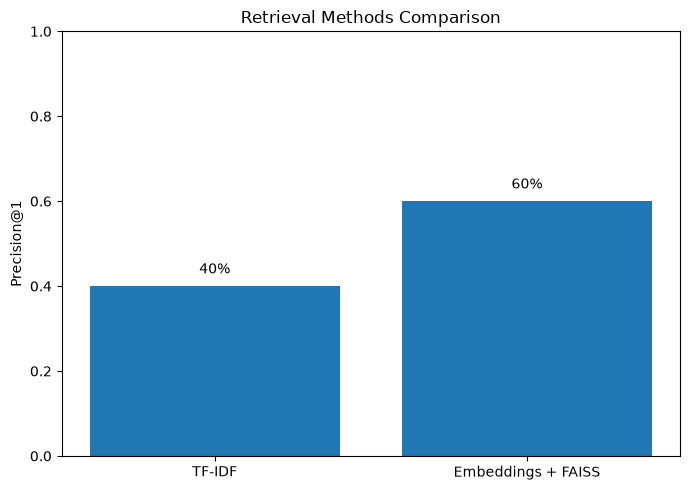

In [12]:
methods = ["TF-IDF", "Embeddings + FAISS"]
precisionScores = [
    float(tfidfPrecisionAt1),
    float(faissPrecisionAt1)
]

plt.figure(figsize=(7, 5))
bars = plt.bar(methods, precisionScores)
plt.title("Retrieval Methods Comparison")
plt.ylabel("Precision@1")
plt.ylim(0, 1)

for bar, score in zip(bars, precisionScores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        min(score + 0.03, 0.97),
        f"{score:.0%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 13. Visualize query-to-chunk similarity

The heatmap shows semantic similarity between each test question and every chunk. Higher values indicate closer vector similarity, but relevance still needs human checking.

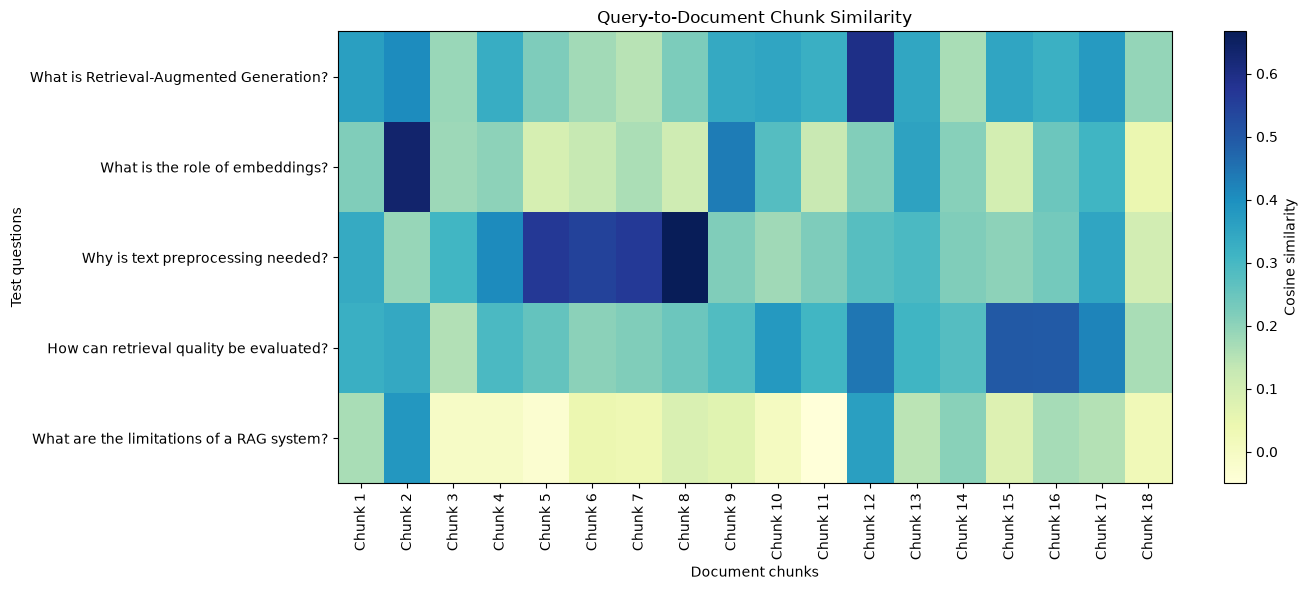

In [13]:
queryTexts = list(relevantPages.keys())
queryEmbeddings = model.encode(
    queryTexts, convert_to_numpy=True
).astype("float32")
faiss.normalize_L2(queryEmbeddings)

similarityMatrix = queryEmbeddings @ normalizedEmbeddings.T

fig, ax = plt.subplots(figsize=(14, 6))
image = ax.imshow(similarityMatrix, aspect="auto", cmap="YlGnBu")
ax.set_title("Query-to-Document Chunk Similarity")
ax.set_xlabel("Document chunks")
ax.set_ylabel("Test questions")
ax.set_xticks(range(len(chunks)))
ax.set_xticklabels([f"Chunk {i + 1}" for i in range(len(chunks))], rotation=90)
ax.set_yticks(range(len(queryTexts)))
ax.set_yticklabels(queryTexts)
fig.colorbar(image, ax=ax, label="Cosine similarity")
fig.tight_layout()
plt.show()

## 14. Save evaluation results

The CSV can be used as evidence in the project report. The charts can be saved separately for inclusion in the report if needed.

In [14]:
os.makedirs("results", exist_ok=True)

evaluationResults.to_csv(
    os.path.join("results", "retrieval_evaluation.csv"),
    index=False
)
answerResults.to_csv(
    os.path.join("results", "answer_generation_results.csv"),
    index=False
)

print("Saved:")
print("- results/retrieval_evaluation.csv")
print("- results/answer_generation_results.csv")

Saved:
- results/retrieval_evaluation.csv
- results/answer_generation_results.csv


## 15. Findings, limitations, and next steps

- The test set contains only five questions and one six-page test PDF, so the results are preliminary.
- Page relevance is manually assigned and should be reviewed if the study material changes.
- TF-IDF relies on word overlap; semantic retrieval can identify related wording but can still return irrelevant passages.
- Answer generation is extractive sentence selection, not free-form generation. It may omit context or select an incomplete sentence.
- Scanned PDFs may need OCR. Larger or varied study documents are needed for more meaningful evaluation.
- The next implementation stage is a user interface that allows a student to upload study material, ask a question, read the answer, and inspect its source page.